This Notebook is related to <b>[Video 4 - Coming out!](https://www.youtube.com/watch?v=Y7KCMaBDeDM)</b>. We will forecast the Moving Average and the process is:
1. Define if the data squence is stationary or not.
2. Run Transformation using <i>(First-ordering Differencing)</i>
3. Check the autocorrelation using ACF plot.
4. If the data is stationary & autocorrelated <b>then we will the lag value from ACF plot to forecast & predict the testing data points.</b>
5. Utilize *Naive Forecasting Methods* (The Average Value, The Last Value, Moving Average(q=7)).
6. Use MSE score to find the best naive method that we can set as a baseline for the model analysis.


* The original dataset has various stocks data sequences, I chose `JNJ` stock because it has the largest data points among them all.

In [17]:
# Import initial libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import seaborn as sns
import warnings

# Import time series libraries
import statsmodels.api as sm
import statsmodels.tsa.api as smt
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Suppress warnings
warnings.filterwarnings("ignore", message="Non-invertible starting MA parameters found")
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [2]:
# Importing the raw dataset
df = pd.read_csv("https://raw.githubusercontent.com/RonySoliman/Time-Series-Forecasting/refs/heads/main/data/Part%202%3A%20Time%20Series%20Forecasting%3A%20The%20Random%20Walk/data.csv")

<b>
The original dataset has 10 unique stocks, but I will use only one stock (JNJ). Because each stock has its own distinct features. They are not equal in the amount of rows, JNJ is the biggest of them all. However it's worth mentioning that we analyze only the data of the last 4 years. Because <i>Random Walk</i> does not work well on a large dataset.
</b>

In [3]:
# Create a new sub-set with a different stock this time!
BAC = df[df['Stock_Name'] == 'BAC'].copy()
# work on the date column
BAC['Date'] = pd.to_datetime(BAC['Date'])
BAC['Year'] = BAC['Date'].dt.year

# Aggregate the annual mean close of the stock
yearly_close = BAC.groupby('Year')['Close'].mean()

# Reset the index to avoid any inaccurate outcome
BAC = BAC.reset_index(drop=True)

In [4]:
# Extract the last 5 years to work on them
latest_date = pd.to_datetime(BAC['Date'].max()).date()
five_years_ago = latest_date - pd.DateOffset(years=5)
BAC_last_five_years = BAC[BAC['Date'] >= pd.to_datetime(five_years_ago)]
BAC_last_five_years = BAC_last_five_years.reset_index(drop=True)

# Print the values
print(f"Data for the last two years (BAC): {five_years_ago.strftime('%Y-%m-%d')} to {latest_date.strftime('%Y-%m-%d')}")
display(BAC_last_five_years.head())

Data for the last two years (BAC): 2017-12-12 to 2022-12-12


,Date,Low,Open,Volume,High,Close,Adjusted Close,Stock_Name,Year
0,2017-12-12,28.910000,29.320000,76017200,29.500000,29.320000,26.285177,BAC,2017
1,2017-12-13,28.830000,29.309999,79980600,29.440001,28.840000,25.854862,BAC,2017
2,2017-12-14,28.709999,29.059999,60615800,29.180000,28.730000,25.756245,BAC,2017
3,2017-12-15,28.740000,28.910000,129859400,29.180000,29.040001,26.034164,BAC,2017
4,2017-12-18,29.270000,29.290001,70548600,29.500000,29.480000,26.428617,BAC,2017


<b>
We can identify the rising trend in the next line graph, that tells us that the data is not stationary; and we need to apply a transformation method such as <i>First-ordering differencing</i> to ensure that the trend effect is minimized.
</b>

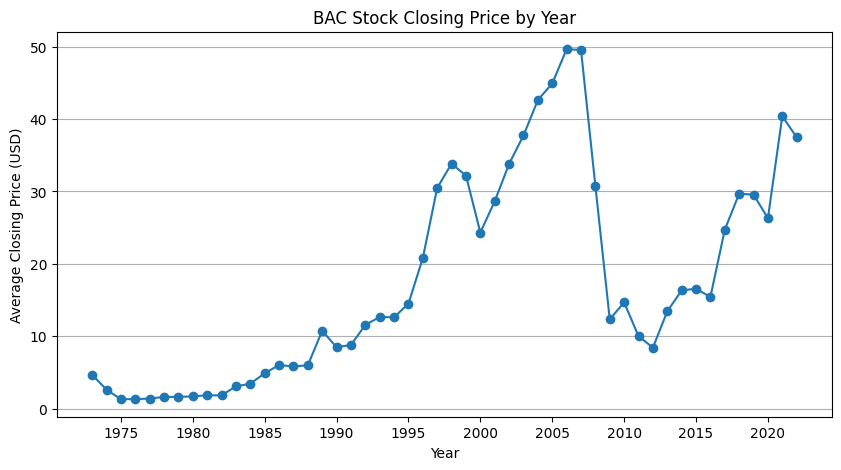

In [18]:
# Plot
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(yearly_close.index, yearly_close.values, marker='o')

# Set labels
ax.set_xlabel("Year")
ax.set_ylabel("Average Closing Price (USD)")
ax.set_title("BAC Stock Closing Price by Year")

# Force x-axis to show ticks every 5 years
ax.xaxis.set_major_locator(MultipleLocator(5))

# To have these horizonal lines and plotting
plt.grid(axis='y')
plt.show();

# We can see the gradual trend between 1970 - 2020. We conclude that the data is not stationary.

In [5]:
# Applying the first-ordering differencing technique
diff_random_walk = np.diff(BAC_last_five_years['Close'], n=1)
diff_random_walk

array([-0.47999954, -0.11000061,  0.31000137, ..., -0.30000305,
       -0.05999756,  0.17499924])

<b>
In the next cell, we can see the following results:

Since the ADF Statistic is negative number a little far from zero & the p-value is drastically diminutive. We can confirm that the data transformation is accurate and the data is now stationary.
</b>

In [6]:
# Check the ADF test
ADF_result = adfuller(diff_random_walk)
print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')

# We can conclude that the ADF Statistic value is largely negative & the p-value is significant.
# So we confirmly can say that the raw time series data is now stationary.

ADF Statistic: -10.947485646077913
p-value: 8.970455739070263e-20


<b>
The resulting in the next ACF plot. You can notice that there are significant
coefficients up until lag 7. Then they abruptly become non-significant, as they remain in the shaded area of the plot. This means that we have a stationary moving average process of order 7. We can use a second-order moving average model, or MA(7) model, to forecast our stationary time series.
</b>

<Figure size 1000x800 with 0 Axes>

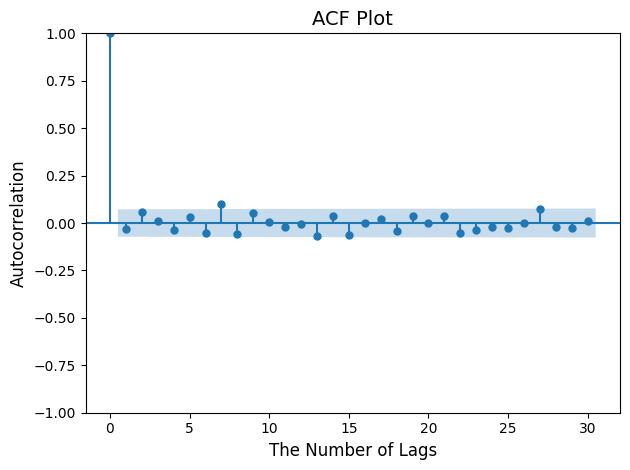

In [7]:
# Plot ACF
plt.figure(figsize=(10,8))
plot_acf(diff_random_walk, lags=30, alpha = 0.01)
plt.title('ACF Plot', fontsize=14)
plt.xlabel('The Number of Lags', fontsize=12)
plt.ylabel('Autocorrelation', fontsize=12)

plt.tight_layout()
plt.show();

### Splitting the data sequence into training & testing subsets

In [8]:
# This new subset the "Close variable" from our original BAC(Close)
data = pd.DataFrame({'diff_random_walk': diff_random_walk})
print('The Shape of the BAC[Close] subset is: ', data.shape);

The Shape of the BAC[Close] subset is:  (1258, 1)


In [9]:
# Defining the training & testing subsets
train = data[:1000].copy()
test = data[1000:].copy()

print(train.shape, test.shape);

(1000, 1) (258, 1)


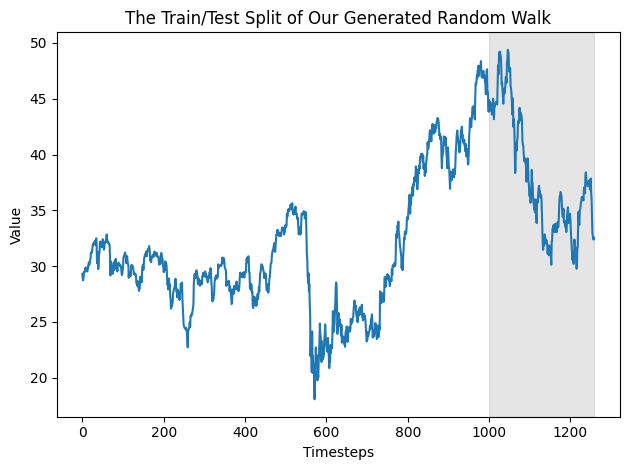

In [10]:
# The plot shows the flow of the data sequence, the grey vertical area represents the testing subset
fig, ax = plt.subplots()

ax.plot(BAC_last_five_years.Close)
ax.set_title('The Train/Test Split of Our Generated Random Walk')
ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')
ax.axvspan(1001, 1259, color='#808080', alpha=0.2)

plt.tight_layout()
plt.show();

In [11]:
# The 1st Naive Forecasting Method (The Average)
mean = np.mean(train.diff_random_walk)
test.loc[:, 'pred_mean'] = mean
test.head();

In [12]:
# The 2nd Naive Forecasting Method (The Last Value)
last_value = train.iloc[-1].diff_random_walk
test.loc[:, 'pred_last'] = last_value
test.head();

In [13]:
# The 3rd Forecasting Method (SARIMAX)
train_len = len(train)
horizon = len(test)
window = 7

pred_MA = []

# Use the differenced data for modeling
for i in range(train_len, train_len + horizon, window):
    # Train on differenced data (stationary)
    current_train_data = data[:i]  # This is diff_random_walk
    model = SARIMAX(current_train_data, order=(0,0,2))
    res = model.fit(disp=False)

    # Predict only the next window steps out-of-sample
    predictions = res.get_prediction(start=i, end=i + window - 1)
    oos_pred = predictions.predicted_mean.values
    pred_MA.extend(oos_pred)

# Assign predictions
test.loc[:, 'pred_sarimax'] = pred_MA[:horizon]

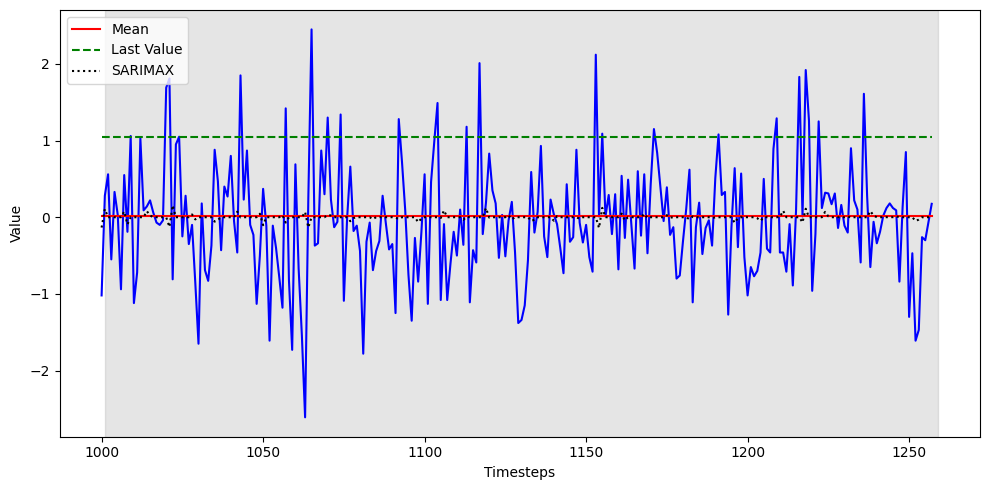

In [14]:
# Visualize the three methods with the Close unique data sequence
fig, ax = plt.subplots(figsize=(10,5))

#ax.plot(diff_random_walk, 'b-')
ax.plot(test.diff_random_walk, 'b-')
ax.plot(test.pred_mean, 'r-', label = 'Mean')
ax.plot(test.pred_last, 'g--', label = 'Last Value')
ax.plot(test.pred_sarimax, 'k:', label = 'SARIMAX')

ax.axvspan(1001, 1259, color='#808080', alpha = 0.2)
ax.legend(loc=2)

ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')

plt.tight_layout()
plt.show();

# As you can see that the three methods rn are failing to capture the unpredictable testing data points, we need to modify our approach.

In [15]:
# Importing Model Evaluation Metrics
from sklearn.metrics import mean_squared_error

# Run MSE on the 3 Naive Methods & then print the results
mse_mean = mean_squared_error(test.diff_random_walk, test.pred_mean)
mse_last = mean_squared_error(test.diff_random_walk, test.pred_last)
mse_sarimax = mean_squared_error(test.diff_random_walk, test.pred_sarimax)

print(f"Mean MSE: {round(mse_mean, 2)}")
print(f"Last Value MSE: {round(mse_last, 2)}")
print(f"SARIMAX MSE: {round(mse_sarimax, 2)}");

Mean MSE: 0.59
Last Value MSE: 1.79
SARIMAX MSE: 0.59


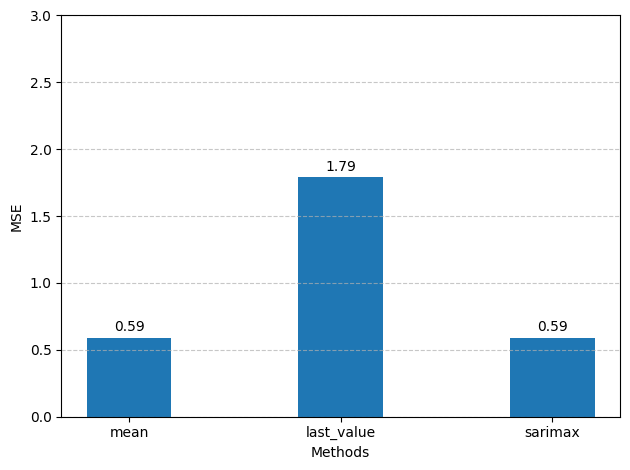

In [16]:
# Visualize the MSE results
fig, ax = plt.subplots()

x = ['mean', 'last_value', 'sarimax']
y = [mse_mean, mse_last, mse_sarimax]

ax.bar(x, y, width=0.4)
ax.set_xlabel('Methods')
ax.set_ylabel('MSE')
ax.set_ylim(0, 3)

for index, value in enumerate(y):
    plt.text(x=index, y=value+0.05, s=str(round(value, 2)), ha='center')

ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show();

# As you can see that the (Mean) & (Moving Average) method outperform the (Last Value) method.

**Conclusion:**

We can conclude that both the Average Value & the Moving Average at Lag = 7 are the solid Naive Forecasting Methods; we can rely on as benchmarks unnecessary complex ML models. If you decided to apply one of the **Tabular ML Algorithms** on this dataset, `0.59` as MSE score is your baseline to ensure that the ML model isn't overfitting or unrealistic.